In [1]:
!pip install transformers==4.28.0
!pip install datasets

In [2]:
import re
import string
import tensorflow as tf

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer
from transformers import AdamW, get_linear_schedule_with_warmup, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
train = pd.read_csv("/content/train_dataset.csv")
validation = pd.read_csv("/content/validation_dataset.csv")
test = pd.read_csv("/content/test_dataset.csv")

In [5]:
import datasets
import pandas as pd
from datasets import Dataset, DatasetDict

train_df = pd.DataFrame({
     "text" : train["Translated_Text"],
     "labels" : train['label']

})
val_df = pd.DataFrame({
     "text" : validation["Translated_Text"],
     "labels" : validation['label']

})

test_df = pd.DataFrame({
     "text" : test["Translated_Text"],
     "labels" : test['label']

})

train_dataset = Dataset.from_dict(train_df)
val_dataset = Dataset.from_dict(val_df)
test_dataset = Dataset.from_dict(test_df)
dataset = datasets.DatasetDict({"train":train_dataset,"validation":val_dataset,"test":test_dataset})

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 862
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 96
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 240
    })
})

In [7]:
dataset.num_rows

{'train': 862, 'validation': 96, 'test': 240}

In [8]:
dataset['train'][0]

{'text': 'το μεγαλύτερο σημάδι του ουαλί του αλλάχ είναι ότι έχει επίγνωση του παρόντος ούτε μετανιώνει για το παρελθόν ούτε φοβάται το μέλλον',
 'labels': 0}

In [9]:
train.head()

,Tweets,label,Translated_Text
0,the greatest sign of the wali of allah is that...,0,το μεγαλύτερο σημάδι του ουαλί του αλλάχ είναι...
1,the oneyearold boy who was tortured so much by...,0,το ενός έτους αγόρι που βασανίστηκε τόσο πολύ ...
2,every person who pays for the pashtun tahafuz ...,0,κάθε άτομο που πληρώνει για το κίνημα των παστ...
3,gee you have found a good similarity but the r...,0,γκι έχετε βρει μια καλή ομοιότητα αλλά ο πραγμ...
4,ahsan iqbal is giving bashan like nawaz sharif...,0,ο άχσαν ικμπάλ δίνει μπάσαν όπως ο ναουάζ σαρί...


In [10]:
test.head()

,Tweets,label,Translated_Text
0,neither agreed in any matter nor united in any...,0,ούτε σύμφωνοι σε κανένα θέμα ούτε ενωμένοι σε ...
1,oh they are sick and silent without honor ask ...,0,ω είναι άρρωστοι και σιωπηλοί χωρίς τιμή ρωτήσ...
2,stop the nonsense you pigs,1,σταματήστε τις ανοησίες γουρούνια
3,vote for me before the election i will hang th...,1,ψηφίστε με πριν τις εκλογές θα κρεμάσω τους κλ...
4,where will they have so much courage to break ...,1,πού θα έχουν τόσο κουράγιο να σπάσουν τα πόδια...


In [11]:
validation.head()

,Tweets,label,Translated_Text
0,thieves miscreants escaped from the court this...,1,οι κλέφτες οι παραβάτες διέφυγαν από το δικαστ...
1,modi should remember that millions of young pe...,1,ο μόντι πρέπει να θυμάται ότι εκατομμύρια νέοι...
2,you are the dogs tail that was tied for twelve...,0,είσαι η ουρά του σκύλου που ήταν δεμένη για δώ...
3,i drink a lot of tea cigarettes and tears of b...,0,πίνω πολύ τσάι τσιγάρα και δάκρυα από αίμα
4,there is some hope now,0,υπάρχει κάποια ελπίδα τώρα


#Hyperparameters

In [12]:
num_epoch = 10
sq_len = 128
batch_size = 32
lr_rate = 3e-5
epsilon = 1e-8
hidden_dropout = 0.05
warmup_ratio = 0.06
weight_decay = 0.01

In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('setu4993/LaBSE')

def encode_batch(batch):
  """Encodes a batch of input data using the model tokenizer."""
  return tokenizer(batch["text"], max_length=sq_len, truncation=True, padding="max_length")

# Encode the input data
dataset = dataset.map(encode_batch, batched=True)
# The transformers model expects the target class column to be named "labels"
#dataset.rename_column_("label", "labels")
# Transform to pytorch tensors and only output the required columns
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/862 [00:00<?, ? examples/s]

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

In [14]:
# Calculation of the maximum length of any text in terms of tokens

max_len = 0

# Concatenate all datasets
all_texts_df = pd.concat([train["Translated_Text"], validation["Translated_Text"], test["Translated_Text"]])

# Iterate through each text in the dataset
for text in all_texts_df:
    input_ids = tokenizer.encode(text, add_special_tokens=True)
    max_len = max(max_len, len(input_ids))

print(f"The maximum length of any text in terms of tokens is: {max_len}")


The maximum length of any text in terms of tokens is: 110


In [15]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 862
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 96
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 240
    })
})

## Training

In [16]:
from transformers import AutoConfig, AutoModelForSequenceClassification

# Model and training configuration
config = AutoConfig.from_pretrained('setu4993/LaBSE',
                                    num_labels=2,
                                    problem_type="single_label_classification")

config.hidden_dropout_prob = hidden_dropout
model = AutoModelForSequenceClassification.from_pretrained('setu4993/LaBSE', config=config)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at setu4993/LaBSE and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [18]:
# Define the function to compute the metrics during evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,precision_score,recall_score,confusion_matrix
import time
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    precision = precision_score(labels, preds, average='weighted',zero_division=0)
    recall = recall_score(labels, preds, average='weighted',zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}



In [19]:
optimizer = AdamW(model.parameters(), lr=lr_rate, eps=epsilon)
total_steps = len(dataset["train"]) * num_epoch
warmup_steps = int(total_steps * warmup_ratio)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [20]:
from datetime import datetime
import pandas as pd

# Create empty lists to store results
epoch_list = []
training_loss_list = []
validation_loss_list = []
training_time_list = []
validation_time_list = []
validation_accuracy_list = []
validation_f1_list = []

test_tp_list = []
test_tn_list = []
test_fp_list = []
test_fn_list = []

test_accuracy_list = []
test_f1_list = []
test_precision_list = []
test_recall_list = []
# Define the trainer Arguments
training_args = TrainingArguments(
          output_dir='./results',
          overwrite_output_dir='True',
          num_train_epochs=1,
          per_device_train_batch_size=batch_size,
          per_device_eval_batch_size=batch_size,
          warmup_ratio=warmup_ratio,
          weight_decay=weight_decay,
          logging_dir='./logs',
          logging_steps=100,
          save_strategy='no',
          evaluation_strategy='no',
          load_best_model_at_end=True,
          metric_for_best_model='accuracy',
          greater_is_better=True,


    )

train_epoch = num_epoch
# Train the model and track the metrics after each epoch
for epoch in range(train_epoch):


    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        # optimizers=(optimizer, None)
    )


    # Train the model for one epoch
    start_time = datetime.now()
    train_result = trainer.train()
    end_time = datetime.now()

    # Perform optimization steps
    optimizer.step()


    # Clear gradients
    optimizer.zero_grad()

    # Perform evaluation on the validation set
    validation_result = trainer.evaluate(eval_dataset=dataset["validation"])

    # Perform evaluation on the test set
    test_result = trainer.evaluate(eval_dataset=dataset["test"])


    # Extract the desired information
    training_loss = train_result.training_loss
    validation_loss = validation_result["eval_loss"]

    validation_time = validation_result["eval_runtime"]
    training_time = train_result.metrics["train_runtime"]

    validation_accuracy = validation_result["eval_accuracy"]
    validation_f1 = validation_result["eval_f1"]


    test_accuracy = test_result["eval_accuracy"]
    test_f1 = test_result["eval_f1"]
    test_precision = test_result["eval_precision"]
    test_recall = test_result["eval_recall"]

    test_tp = test_result["eval_tp"]
    test_tn = test_result["eval_tn"]
    test_fp = test_result["eval_fp"]
    test_fn = test_result["eval_fn"]

    val_runtime_formatted = pd.to_datetime(validation_time, unit='s').strftime('%H:%M:%S')
    train_runtime_formatted = pd.to_datetime(training_time, unit='s').strftime('%H:%M:%S')

    # Append the metrics to the respective lists
    epoch_list.append(epoch + 1)
    training_loss_list.append(training_loss)
    validation_loss_list.append(validation_loss)

    validation_accuracy_list.append(validation_accuracy)
    validation_f1_list.append(validation_f1)

    training_time_list.append(train_runtime_formatted)
    validation_time_list.append(val_runtime_formatted)

    test_tp_list.append(test_tp)
    test_tn_list.append(test_tn)
    test_fp_list.append(test_fp)
    test_fn_list.append(test_fn)


    test_accuracy_list.append(test_accuracy)
    test_f1_list.append(test_f1)
    test_precision_list.append(test_precision)
    test_recall_list.append(test_recall)

# Create a DataFrame to store the results
train_df = pd.DataFrame({
    "Epoch": epoch_list,
    "Training Loss": training_loss_list,
    "Validation Loss": validation_loss_list,
    "Validation Accuracy": validation_accuracy_list,
    "Validation F1": validation_f1_list,
    "Training Time": training_time_list,
    "Validation Time": validation_time_list,
})

test_df = pd.DataFrame({
    "Epoch": epoch_list,
    "Test TP": test_tp_list,
    "Test TN": test_tn_list,
    "Test FP": test_fp_list,
    "Test FN": test_fn_list,
    "Test Accuracy": test_accuracy_list,
    "Test F1": test_f1_list,
    "Test Precision": test_precision_list,
    "Test Recall": test_recall_list,
})

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss


In [21]:
train_df.head(10)

,Epoch,Training Loss,Validation Loss,Validation Accuracy,Validation F1,Training Time,Validation Time
0,1,0.555697,0.417188,0.802083,0.801025,00:00:10,00:00:00
1,2,0.358790,0.399354,0.843750,0.842365,00:00:07,00:00:00
2,3,0.256914,0.544593,0.833333,0.829712,00:00:07,00:00:00
3,4,0.289330,0.854558,0.843750,0.839840,00:00:06,00:00:00
4,5,0.364438,1.478666,0.791667,0.784076,00:00:06,00:00:00
5,6,0.280449,1.213403,0.843750,0.841671,00:00:07,00:00:00
6,7,0.409835,1.135067,0.822917,0.822744,00:00:06,00:00:00
7,8,0.230589,1.310351,0.843750,0.841671,00:00:06,00:00:00
8,9,0.257880,1.293805,0.822917,0.822897,00:00:06,00:00:00
9,10,0.212976,1.351448,0.812500,0.812500,00:00:06,00:00:00


In [22]:
test_df.head(10)

,Epoch,Test TP,Test TN,Test FP,Test FN,Test Accuracy,Test F1,Test Precision,Test Recall
0,1,98,100,20,22,0.825000,0.824988,0.825090,0.825000
1,2,101,108,12,19,0.870833,0.870723,0.872100,0.870833
2,3,89,109,11,31,0.825000,0.823776,0.834286,0.825000
3,4,94,109,11,26,0.845833,0.845229,0.851323,0.845833
4,5,85,113,7,35,0.825000,0.822585,0.843713,0.825000
5,6,92,109,11,28,0.837500,0.836681,0.844412,0.837500
6,7,110,99,21,10,0.870833,0.870561,0.873976,0.870833
7,8,100,108,12,20,0.866667,0.866518,0.868304,0.866667
8,9,112,100,20,8,0.883333,0.883041,0.887205,0.883333
9,10,109,102,18,11,0.879167,0.879064,0.880461,0.879167


#Store Results in Excel File

In [23]:
train_df.to_excel("Train LaBSE-128SL-32BS-0.05HD-0.06WR-0.01WD.xlsx")

In [24]:
test_df.to_excel("Test LaBSE-128SL-32BS-0.05HD-0.06WR-0.01WD.xlsx")

## SHAP

In [25]:
!pip install shap

In [26]:
import scipy as sp
import numpy as np
import torch
import shap

# Prediction function
def f(x):
    tv = torch.tensor(
        [
            tokenizer.encode(v, padding="max_length", max_length=128, truncation=True)
            for v in x
        ]
    ).cuda()
    outputs = model(tv)[0].detach().cpu().numpy()
    scores = (np.exp(outputs).T / np.exp(outputs).sum(-1)).T
    val = sp.special.logit(scores[:, 1])
    return val

# SHAP explainer
explainer = shap.Explainer(f, tokenizer)

# Explanation of the model's predictions on the test dataset
shap_values = explainer(test['Translated_Text'].values[3:5])  # instances which have labelled with hate speech

# Plot
shap.plots.text(shap_values)

/usr/local/lib/python3.10/dist-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/usr/local/lib/python3.10/dist-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(all_masks, max_swap_size=100, num_

The SHAP visualization above shows the effect of different words on the model prediction scores. The words in red push the prediction to one class and swipe the others in blue to the opposite class.

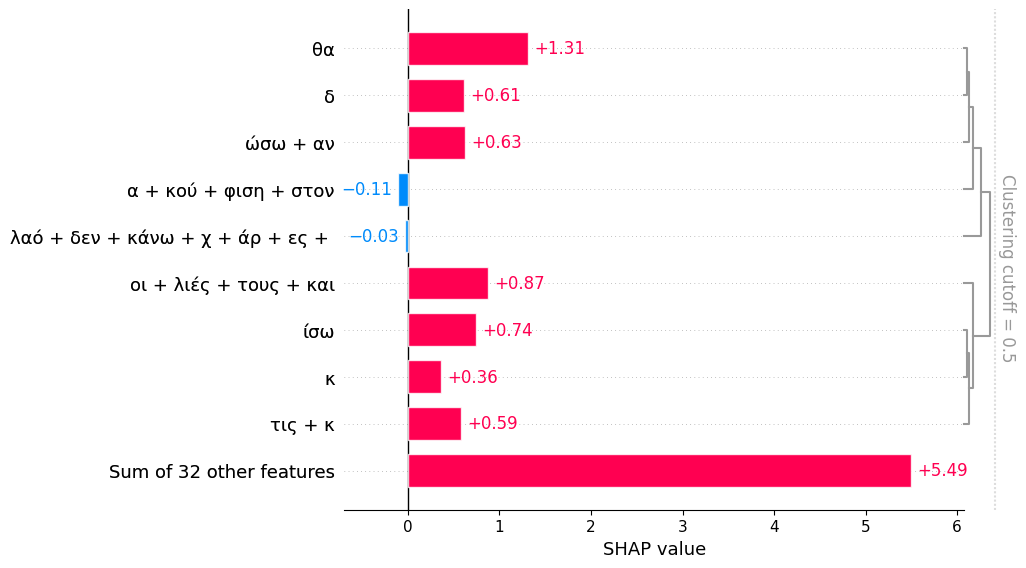

In [27]:
# Bar plot of Shap values
shap.plots.bar(shap_values[0]) # for instance 0

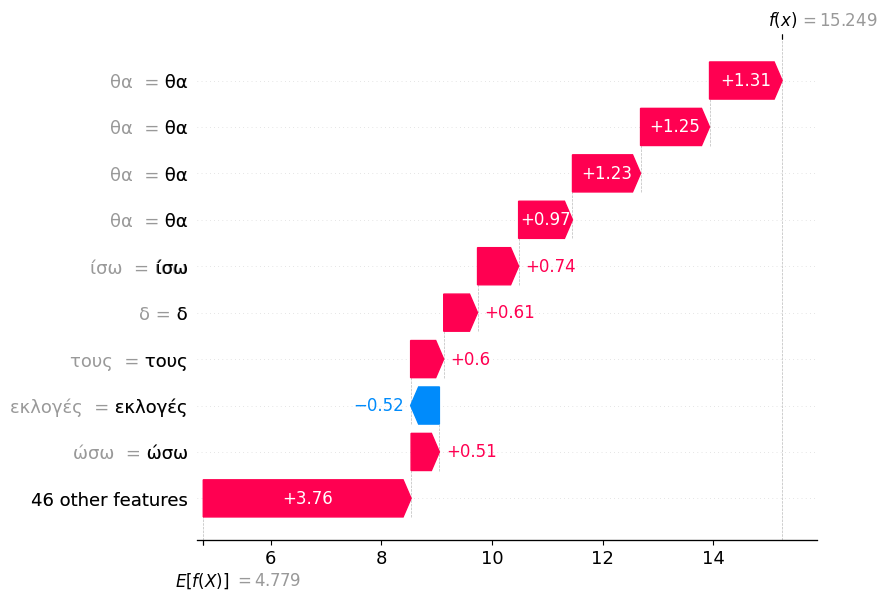

In [28]:
# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[0]) # for instance 0

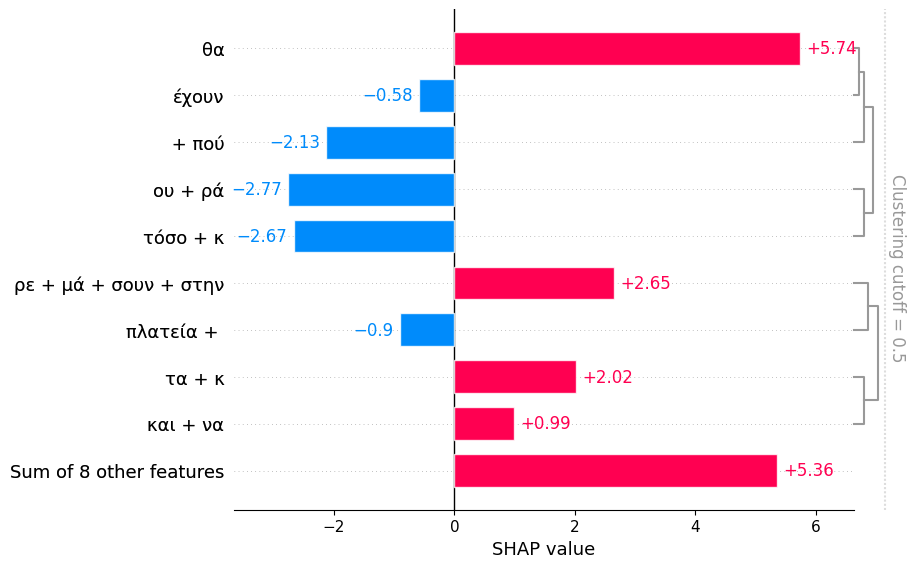

In [54]:
# Bar plot of Shap values
shap.plots.bar(shap_values[1]) # for instance 1

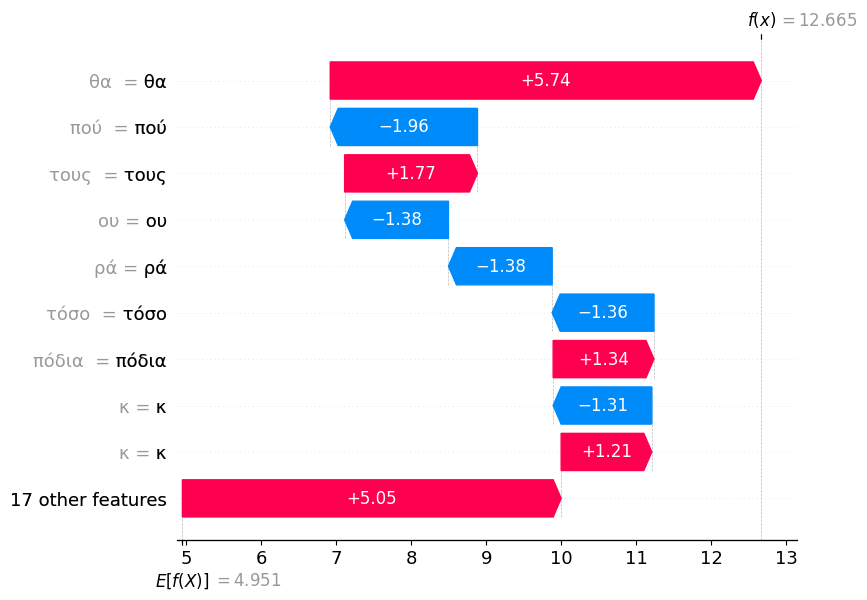

In [55]:
# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[1]) # for instance 1

## Lime

In [29]:
!pip install lime

In [49]:
from lime.lime_text import LimeTextExplainer
from lime import lime_text
import torch.nn.functional as F
import torch

# Evaluation mode
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

def predictor(texts):
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=1)

    return predictions.cpu().numpy()

# LIME explainer
explainer = LimeTextExplainer(class_names=['Not Threat', 'Threat'])

#The text we want to explain
random_text_instance = test["Translated_Text"].sample(n=1).iloc[0]


# Explanation for the test instance
exp = explainer.explain_instance(
    random_text_instance,
    classifier_fn=predictor,
    num_features=10,
)

# Display
exp.show_in_notebook(text=True)

In [50]:
# Feature names and their weights from the explanation
feature_names = np.array([feature[0] for feature in exp.as_list()])
weights = np.array([feature[1] for feature in exp.as_list()])

In [51]:
# Top features and top weights
num_top_features = 10
top_features = feature_names[:num_top_features]
top_weights = weights[:num_top_features]

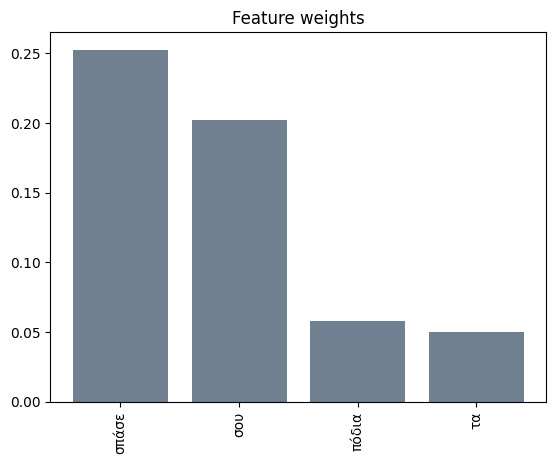

In [52]:
import matplotlib.pylab as plt
# Bar graph of classification of instances
plt.bar(top_features, top_weights, color='slategray')
plt.xticks(rotation=90)
plt.title('Feature weights')
plt.show()